# Notebook 01 — DETR Architecture

From image classification to object detection: understanding DETR — the first end-to-end object detector using a pure transformer.

---

## Table of Contents

1. [From Classification to Detection](#1-from-classification-to-detection)
2. [DETR Architecture Overview](#2-detr-architecture-overview)
3. [CNN Backbone](#3-cnn-backbone)
4. [Transformer Encoder-Decoder](#4-transformer-encoder-decoder)
5. [Bipartite Matching](#5-bipartite-matching)
6. [Running Inference](#6-running-inference)

---

## 1. From Classification to Detection

### What you built in app-01: Classification

In app-01 you trained a ViT to classify images. The task was simple in structure:
- **Input:** one image
- **Output:** one label (e.g., "cat")
- **How:** a CLS token aggregates information from all patches, then a linear head maps it to a class

### What detection adds: location

Object detection requires the model to do two things simultaneously:
- **Classify:** what objects are in the image?
- **Localize:** where is each object? (bounding box: `[x, y, w, h]`)

And the number of objects varies per image — an image might have 1 cat or 12 people. This variable-length output is what makes detection fundamentally harder than classification.

### Why traditional detectors are complicated

Before DETR, detectors like Faster R-CNN and YOLO used a set of handcrafted components to handle this:

1. **Anchor boxes** — predefined bounding box shapes tiled across the image at multiple scales. The model predicts offsets from these anchors rather than raw coordinates.
2. **Region proposal networks** — a separate sub-network that proposes candidate regions likely to contain objects.
3. **Non-Maximum Suppression (NMS)** — because anchors overlap heavily, the model produces many duplicate detections for the same object. NMS is a post-processing step that removes duplicates: it keeps the box with the highest confidence score and suppresses nearby boxes with high overlap (IoU > threshold).

NMS works well in practice but has a problem: it's a hand-tuned heuristic, not learned. The threshold is fixed, it struggles with dense scenes, and it cannot be trained end-to-end.

### What makes DETR different

DETR (Detection Transformer, Carion et al. 2020) reframes detection as a **set prediction problem**:

- Instead of predicting offsets from anchors, DETR predicts a fixed set of N=100 (class, box) pairs directly.
- Instead of NMS to remove duplicates, DETR uses the **Hungarian algorithm** during training to enforce one-to-one matching between predictions and ground truth objects.
- The result: a pipeline with no anchors, no NMS, no hand-tuned components — just a CNN backbone and a transformer.

In [1]:
import torch
import torchvision
from transformers import DetrImageProcessor, DetrForObjectDetection
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import requests
from pathlib import Path

# Use MPS on Apple Silicon if available, otherwise CPU
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

/Users/preetichauhan/anaconda3/envs/codingenv/lib/python3.11/site-packages/transformers/utils/generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


Device: mps


---

## 2. DETR Architecture Overview

Here is the full pipeline from input image to detected objects:

```
Input Image
    ↓
CNN Backbone (ResNet-50)     ← extracts spatial features, like patch embedding in ViT
    ↓
Positional Encoding          ← 2D sine/cosine encoding (row + column, not just position)
    ↓
Transformer Encoder          ← same as ViT encoder: self-attention across all spatial locations
    ↓
Transformer Decoder          ← NEW: takes N "object queries" as input, attends to encoder output
    ↓
FFN heads (×N)               ← predicts (class, bounding box) for each of N queries
    ↓
Hungarian Matching           ← matches N predictions to M ground truth objects (N >> M)
```

### Key difference from ViT

| | ViT (app-01) | DETR |
|---|---|---|
| Backbone | Patch embedding (linear) | CNN (ResNet-50) |
| Transformer | Encoder only | Encoder + Decoder |
| Special token | 1 CLS token | 100 object queries |
| Output | 1 class label | 100 (class, box) pairs |
| Post-processing | None | Hungarian matching (training only) |

The transformer encoder in DETR is essentially identical to what you built in app-01. The new piece is the **decoder**, which takes N learnable queries as input and uses cross-attention to find objects in the encoder's output.

---

## 3. CNN Backbone

### Why a CNN instead of patch embedding?

In app-01, ViT divided the image into 16×16 patches and used a linear projection as the embedding. DETR was published in May 2020 — the same month as the original ViT paper. At that time, CNNs were the established and well-understood way to extract rich spatial features from images. ViT was not yet proven at scale.

Modern follow-ups to DETR (like DINO and ViTDet) do use ViT backbones. But the original DETR uses ResNet-50.

### What the backbone does

ResNet-50 is used as a **feature extractor**, not a classifier. The final fully-connected classification layer is removed. What remains outputs a spatial feature map:

```
Input image:       (batch, 3, H, W)          e.g. (1, 3, 800, 1066)
After ResNet-50:   (batch, 2048, H/32, W/32) e.g. (1, 2048, 25, 34)
After 1×1 conv:    (batch, 256, H/32, W/32)  e.g. (1, 256, 25, 34)
After flatten:     (batch, H/32 × W/32, 256) e.g. (1, 850, 256)  ← tokens for the transformer
```

The 1×1 convolution reduces the channel dimension from 2048 to `d_model=256`. After flattening, each spatial location `(i, j)` in the feature map becomes one token — exactly like a patch token in ViT.

### Positional encoding

ViT used 1D positional encoding (one index per patch). DETR uses **2D sine/cosine encoding** — separate encodings for the row and column dimensions, concatenated. This preserves the 2D spatial structure of the image, which matters for localization.

In [2]:
# Load the pretrained DETR model and its image processor from HuggingFace
# The processor handles resizing, normalization, and padding to a fixed size
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
model = model.to(device)
model.eval()  # disable dropout and batch norm training behavior

# Inspect the model configuration
print(f"Model loaded. Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Object queries: {model.config.num_queries}")     # 100 by default
print(f"Number of classes: {model.config.num_labels}")   # 91 COCO classes

/Users/preetichauhan/anaconda3/envs/codingenv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Model loaded. Parameters: 41,524,768
Object queries: 100
Number of classes: 91


---

## 4. Transformer Encoder-Decoder

### Encoder — same as ViT

The encoder takes the flattened CNN feature map as a sequence of tokens and runs standard transformer encoder layers:

```
Input:  (batch, H×W, d_model)   — spatial locations as tokens
  ↓ + positional encoding
  ↓ self-attention (each location attends to all others)
  ↓ feed-forward network
  ↓ ... × 6 layers
Output: (batch, H×W, d_model)   — each location now has global context
```

This is identical in structure to the encoder you built in app-01. Each spatial location can attend to every other location, allowing the model to reason about global scene context before making predictions.

### Decoder — what makes DETR different from ViT

The decoder introduces two new concepts: **object queries** and **cross-attention**.

**Object queries** are N=100 learnable embedding vectors. Think of them as learned "slots" — each one is initialized randomly and learns during training to ask a different question about the image. They are not tied to any spatial location upfront.

The decoder runs 6 layers, each containing:
1. **Self-attention across queries** — queries communicate with each other, preventing multiple queries from detecting the same object
2. **Cross-attention: queries → encoder output** — each query looks at the full encoder output to find evidence of its object
3. **Feed-forward network** — refines each query's representation

```
Input:  100 learned object queries  (batch, 100, d_model)
        Encoder output              (batch, H×W, d_model)
  ↓ self-attention(queries, queries)   — queries talk to each other
  ↓ cross-attention(queries, encoder) — each query attends to spatial features
  ↓ feed-forward network
  ↓ ... × 6 layers
Output: (batch, 100, d_model)         — 100 refined query vectors
```

Each output vector is then fed into a small FFN (feed-forward network) to produce:
- A class logit vector (91 COCO classes + 1 "no object")
- A bounding box prediction (cx, cy, w, h) normalized to [0, 1]

### Connecting to app-01

In app-01, you had ONE CLS token that asked: "what is the whole image?"

In DETR, you have 100 object queries, each asking: "is there an object somewhere in this image, and if so, where?"

The CLS token was prepended to the patch tokens and used self-attention. Object queries use cross-attention to read from the encoder output — they never directly attend to the original image pixels, only to the encoder's enriched spatial representation.

---

## 5. Bipartite Matching

### The problem: which prediction maps to which ground truth?

During training, DETR produces N=100 predictions per image. A typical training image might have M=3 ground truth objects. How do you compute the loss?

You cannot just pair them by index — prediction #1 has no inherent meaning. You need to find the optimal assignment.

### The Hungarian algorithm

The Hungarian algorithm solves the **optimal assignment problem**: given N predictions and M ground truth boxes, find the one-to-one matching that minimizes total cost.

The cost for matching prediction `i` to ground truth `j` is:

```
cost(i, j) = λ_class × classification_cost(i, j)
           + λ_L1    × L1_distance(box_i, gt_box_j)
           + λ_giou  × GIoU_loss(box_i, gt_box_j)
```

Where GIoU (Generalized Intersection over Union) measures bounding box overlap and is differentiable, unlike standard IoU.

**Example with N=100 predictions, M=2 ground truth boxes:**

```
Predictions:  P1(dog, top-left), P2(cat, center), P3(nothing), ..., P100(nothing)
Ground truth: GT1(dog, top-left), GT2(cat, center)

Hungarian matching:
  P1  → GT1  (cost: low — good class + good box)
  P2  → GT2  (cost: low — good class + good box)
  P3...P100 → "no object"  (supervised to predict background)
```

The Hungarian algorithm guarantees:
- Each ground truth box is matched to exactly one prediction
- The total cost across all matches is minimized
- All unmatched predictions (N - M of them) are assigned the "no object" class

### Why this is better than NMS

NMS is applied **after** training, as a post-processing step. It is not differentiable and cannot be optimized. It requires hand-tuning the IoU threshold.

Hungarian matching is part of the **training objective**. The model is explicitly trained so that each object in the image is detected by exactly one query. Duplicate detections are never produced in the first place — they are penalized during training.

This is what DETR's authors mean by "end-to-end": the matching, the loss, and the model parameters are all optimized together.

---

## 6. Running Inference

In [3]:
# Load a sample image from the COCO validation set
# This image contains two cats on a couch — a good test for multi-object detection
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

# The processor resizes the image (longest side <= 1333, shortest side <= 800)
# and normalizes pixel values using ImageNet mean/std
inputs = processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# Run forward pass — no gradients needed at inference time
with torch.no_grad():
    outputs = model(**inputs)

print("Output keys:", list(outputs.keys()))
print("Logits shape:", outputs.logits.shape)       # (1, 100, 92) — 100 queries, 92 classes
print("Boxes shape:", outputs.pred_boxes.shape)    # (1, 100, 4)  — 100 queries, (cx, cy, w, h)

Output keys: ['logits', 'pred_boxes', 'last_hidden_state', 'encoder_last_hidden_state']
Logits shape: torch.Size([1, 100, 92])
Boxes shape: torch.Size([1, 100, 4])


### Understanding the output format

**`outputs.logits`** — shape `(1, 100, 92)`
- 1 image in the batch
- 100 object queries
- 92 class scores: 91 COCO object classes + 1 "no object" class
- Apply softmax to get probabilities; the "no object" class index is 91
- Most queries will have a high probability for "no object" — only a few will find real objects

**`outputs.pred_boxes`** — shape `(1, 100, 4)`
- 100 bounding boxes, one per query
- Format: `(cx, cy, w, h)` normalized to [0, 1] relative to image size
- These are raw predictions from the FFN — every query predicts a box, even "no object" queries

**To get final detections:**
1. Apply softmax to logits
2. For each query, take `argmax` over classes
3. Filter out queries predicted as "no object"
4. Filter by confidence threshold (e.g., 0.7)
5. Convert normalized (cx, cy, w, h) to absolute pixel (x0, y0, x1, y1)

The `processor.post_process_object_detection()` call below does all of this automatically.

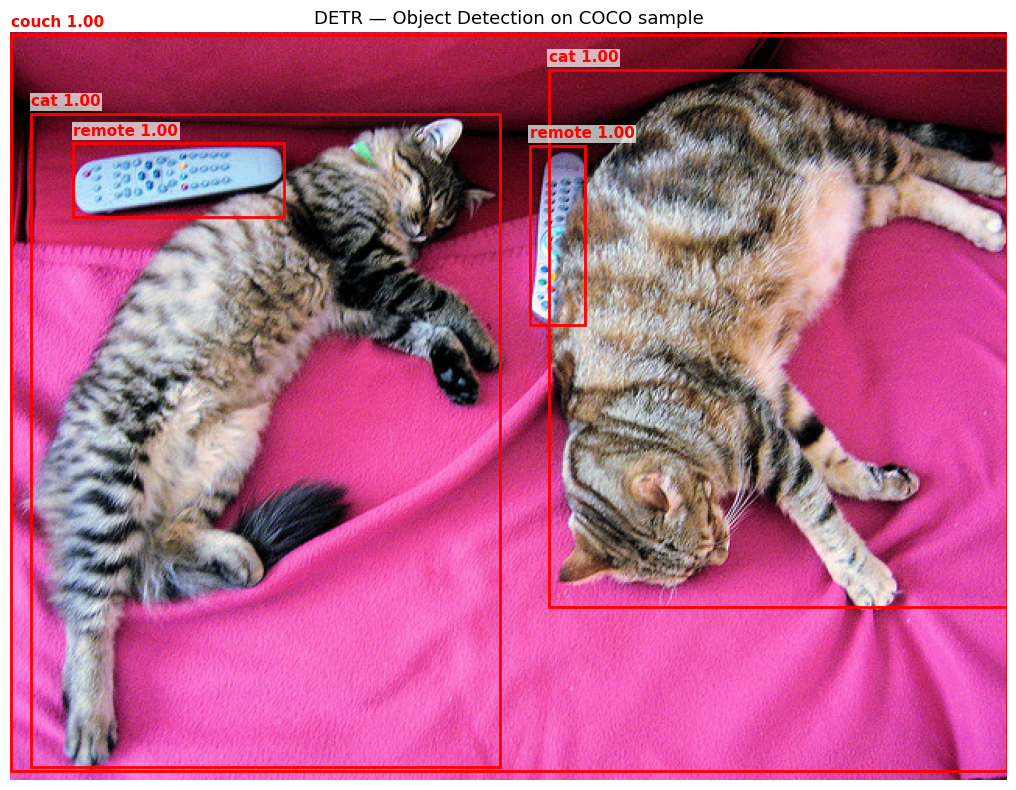

Detected 5 objects


In [4]:
# Post-process: convert normalized boxes to absolute pixel coordinates
# and filter out low-confidence predictions
# target_sizes: (height, width) of the original image — needed for coordinate conversion
target_sizes = torch.tensor([image.size[::-1]]).to(device)  # image.size = (W, H), we need (H, W)
results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.7)[0]

# Plot the original image with predicted bounding boxes
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(image)

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = box.cpu().numpy()
    x0, y0, x1, y1 = box
    w, h = x1 - x0, y1 - y0
    # Draw bounding box
    rect = patches.Rectangle((x0, y0), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    # Add label and confidence score
    label_name = model.config.id2label[label.item()]
    ax.text(x0, y0 - 5, f'{label_name} {score:.2f}', color='red', fontsize=11, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

ax.axis('off')
ax.set_title('DETR — Object Detection on COCO sample', fontsize=13)
plt.tight_layout()

# Save to assets directory (one level up from notebooks/)
assets_dir = Path('../assets')
assets_dir.mkdir(exist_ok=True)
plt.savefig(assets_dir / 'detr_detection.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Detected {len(results['scores'])} objects")

---

### What the Attention Sees

One of DETR's most useful interpretability properties is its decoder cross-attention maps.

Recall the decoder architecture: each object query uses **cross-attention** to read from the encoder output. The attention weights tell you which spatial locations in the encoder feature map the query is focusing on.

When you visualize these attention weights:
- A query that detected a cat will show high attention over the pixels where the cat is
- A query that predicted "no object" shows scattered, low-confidence attention
- Different queries specialize: over training, some learn to find people, others find chairs, etc.

This is very different from NMS-based detectors, where you cannot easily see "which part of the model decided there is a cat here." In DETR, the cross-attention map directly shows the query's evidence.

The attention is extracted from the **last decoder layer** (layer 6 of 6), which produces the final query representations used for prediction. We average across the 8 attention heads to get a single spatial map.

Cross attention shape: torch.Size([1, 8, 100, 850])


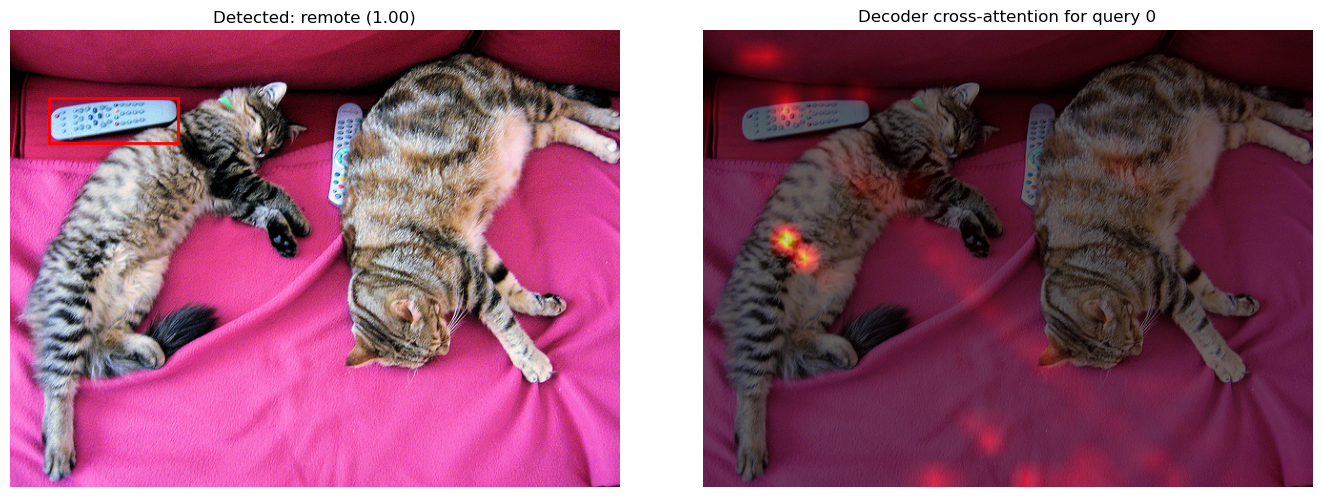

In [5]:
# Re-run inference with output_attentions=True to get cross-attention maps
with torch.no_grad():
    outputs_attn = model(**inputs, output_attentions=True)

# cross_attentions is a list of tensors, one per decoder layer
# Each tensor shape: (batch, num_heads, num_queries, encoder_seq_len)
# encoder_seq_len = H_feat × W_feat (number of spatial tokens from the backbone)
cross_attn = outputs_attn.cross_attentions[-1]  # use the last decoder layer
print(f"Cross attention shape: {cross_attn.shape}")  # (1, 8, 100, H*W)

# Find which queries produced high-confidence detections (from our earlier inference)
keep = results["scores"] > 0.7
query_indices = torch.where(keep)[0]

# Visualize the attention map for the first detected object
if len(query_indices) > 0:
    q_idx = query_indices[0].item()  # index of the first high-confidence query
    
    # Average attention weights across 8 heads for this query
    attn = cross_attn[0, :, q_idx, :].mean(0)  # shape: (encoder_seq_len,)
    
    # Reshape from flat sequence back to 2D spatial grid
    # The backbone downsamples by 32× in each spatial dimension
    h_feat = inputs['pixel_values'].shape[2] // 32
    w_feat = inputs['pixel_values'].shape[3] // 32
    attn_map = attn[:h_feat * w_feat].reshape(h_feat, w_feat).cpu().numpy()
    
    # Plot original image with detected box alongside the attention heatmap
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: detection result
    ax1.imshow(image)
    box = results["boxes"][0].cpu().numpy()
    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                               linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)
    label_name = model.config.id2label[results["labels"][0].item()]
    ax1.set_title(f'Detected: {label_name} ({results["scores"][0]:.2f})', fontsize=12)
    ax1.axis('off')
    
    # Right: cross-attention heatmap overlaid on image
    # extent maps the attention grid coordinates onto pixel coordinates
    ax2.imshow(image)
    ax2.imshow(attn_map, alpha=0.6, extent=[0, image.width, image.height, 0],
               cmap='hot', interpolation='bilinear')
    ax2.set_title(f'Decoder cross-attention for query {q_idx}', fontsize=12)
    ax2.axis('off')
    
    plt.tight_layout()
    plt.savefig(assets_dir / 'detr_attention.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print("No high-confidence detections found. Try lowering the threshold.")

---

## Summary

**What DETR does differently:**

- Detection is reframed as **set prediction** — no anchors, no NMS, no hand-tuned post-processing
- **100 object queries** run in parallel through the transformer decoder; each predicts one (class, box) pair
- **Hungarian algorithm** matches the N=100 predictions to M ground truth boxes during training, enforcing one-to-one assignment so duplicates are never produced
- **Cross-attention** in the decoder is interpretable: the attention map shows exactly where each query found its object

**Tradeoffs:**

- DETR is architecturally clean and elegant — all complexity is in the transformer
- It is slower to train than YOLO (requires ~500 epochs vs ~100 for Faster R-CNN) because the object queries take a long time to learn stable assignments
- At inference time, it is competitive in speed for small object counts but slower for dense scenes (many small objects)
- Later work (Deformable DETR, DAB-DETR, DN-DETR) addresses these training speed issues

**Connection to what you built:**

| app-01 component | DETR equivalent |
|---|---|
| Patch embedding | CNN backbone + 1×1 conv |
| 1D positional encoding | 2D sine/cosine encoding |
| Transformer encoder | Transformer encoder (identical structure) |
| CLS token | 100 object queries |
| Linear classification head | FFN for class + box per query |

---

Next → notebook 02: YOLOv8 fine-tuning and mAP evaluation

[↑ Back to top](#notebook-01----detr-architecture)